Group Members: Nicolas Banatt, Annanya Jain, James McDermott, Yanran Jia

In [274]:
!python --version

Python 3.12.1


In [275]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [276]:
import pandas as pd
import numpy as np

In [277]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [278]:
# Change RRVch (our target) to binary label for classification
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

# 1. Extract the baseline rows (one per participant)
baseline = df[df["Assmnt"] == "baseline"][["ID", "RRVscore"]]
baseline = baseline.rename(columns={"RRVscore": "Baseline_RRVscore"})

# 2. Keep only pstwash and endposttr rows
post = df[df["Assmnt"].isin(["pstwash", "endposttr"])]

# 3. Merge baseline RRVscore onto these rows
merged = post.merge(baseline, on="ID", how="left")

# merged now contains:
#   • all pstwash and endposttr rows
#   • baseline RRVscore appended for each participant

df = merged
df.drop(columns=[])


df.dropna(subset=["Baseline_RRVscore"])

df["Assmnt"] = df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

df = df[df["ID"] != 25]

df = df.drop(columns = ['RRVscore','RRV_Pgoal','RRV_Agoal','Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


## K-Nearest Neighbors

In [279]:
from sklearn.preprocessing import MinMaxScaler
# James

knn_df = df.copy()

knn_df.dropna(subset=["Baseline_RRVscore"])

attr = knn_df.drop(columns = ['RRV_label'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
target = knn_df['RRV_label']  # target variable
attr.head()


,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,0.50
1,10,579.0,229.0,40.0,0.0,0.0,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0.75


In [280]:
scaler = MinMaxScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,0.0,0.277690,0.585714,0.783333,0.571429,0.0,0.50
1,1.0,0.323576,0.530952,0.666667,0.000000,0.0,0.50
2,0.0,0.268987,0.228571,0.183333,0.000000,0.0,0.00
3,1.0,0.276108,0.264286,0.083333,0.000000,0.0,0.00
4,1.0,0.208861,0.700000,0.300000,0.000000,0.0,0.75


In [281]:
from sklearn.model_selection._split import train_test_split

attr_train, attr_test, target_train,target_test  = train_test_split(attr, target, test_size = 0.3, shuffle = True)
target_train.head()
attr_train.head()


,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
70,1.0,0.491297,0.430952,0.433333,0.000000,0.0,0.750000
115,0.0,0.772152,0.652381,0.216667,0.000000,0.0,0.750000
14,1.0,0.248418,0.357143,0.183333,0.000000,0.0,1.000000
67,1.0,0.109968,0.221429,0.466667,0.428571,0.0,0.857143
85,1.0,0.274525,0.457143,0.283333,0.142857,0.0,0.500000


In [282]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 10, 5]
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(attr_train, target_train)
    target_pred = knn.predict(attr_test)
    accuracy = accuracy_score(target_test,target_pred ) 
    print(f'Accuracy of model with k = {k}: {accuracy}')
    print('')

Accuracy of model with k = 3: 0.7027027027027027

Accuracy of model with k = 10: 0.6216216216216216

Accuracy of model with k = 5: 0.6756756756756757



In [283]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(target_test, target_pred)

print('Confusion Matrix')
print(confusion_matrix(target_test, target_pred))
print()
print('Accuracy score')
print(accuracy_score(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

Confusion Matrix
[[18  4]
 [ 8  7]]

Accuracy score
0.6756756756756757

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.82      0.75        22
           1       0.64      0.47      0.54        15

    accuracy                           0.68        37
   macro avg       0.66      0.64      0.64        37
weighted avg       0.67      0.68      0.66        37



In [284]:
test_actual=attr_test
test_actual['target_pred']=target_pred
test_actual['test_actual']=target_test
test_actual.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore,target_pred,test_actual
50,0.0,0.248418,0.828571,0.100000,0.0,0.0,0.857143,0,NaN
94,1.0,0.780854,0.311905,0.250000,0.0,0.0,1.000000,0,NaN
39,1.0,0.134494,0.421429,0.183333,0.0,0.0,1.000000,0,1.0
54,0.0,0.251582,0.688095,0.133333,0.0,0.0,0.000000,0,NaN
59,1.0,0.297468,0.445238,0.600000,0.0,0.0,1.000000,0,NaN


In [285]:
freq_table =pd.crosstab( test_actual['test_actual'], test_actual['target_pred'])
print("Confusion Matrix")
print(freq_table)

Confusion Matrix
target_pred  0  1
test_actual      
0.0          5  3
1.0          5  6


[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

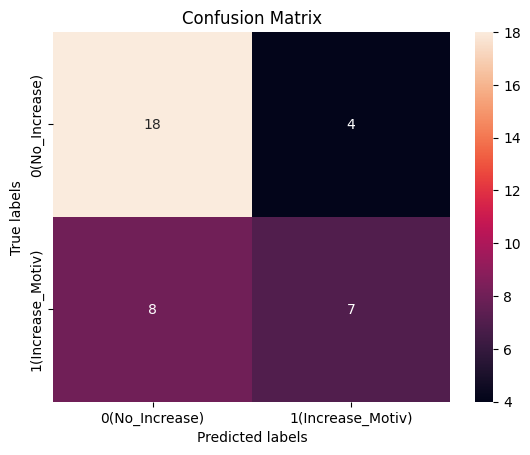

In [286]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])

## CART (Nicolas)

In [287]:
#cart_attr = df.drop(columns = ["Participant", "ID"])

## Naive Bayes

In [288]:
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_columns = ['Assmnt']
continuous_columns = [
    'Avg_Daily_Sed_Week_Min',
    'Avg_Daily_Light_Week_Min',
    'Avg_Daily_Mod_Week_Min',
    'Avg_Daily_Vig_Week_Min',
    'Avg_Daily_Very_Vig_Week_Min',
    'Baseline_RRVscore'
]

# Preprocessing: 
# - OneHotEncode categorical
# - Bin continuous features into 5 quantile bins
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ('disc', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), continuous_columns)
    ]
)

# Now you can use CategoricalNB since all features are discrete
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

# Fit the model
model.fit(attr_train, target_train)

# Make predictions
target_pred = model.predict(attr_test)


c:\Users\enzon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\enzon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\enzon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\enzon\AppData\Local\Pr

In [289]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# Evaluate the accuracy
accuracy = accuracy_score(target_test, target_pred)
print(f'Accuracy: {accuracy}')
print()
print(confusion_matrix(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

Accuracy: 0.6756756756756757

[[20  2]
 [10  5]]

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.91      0.77        22
           1       0.71      0.33      0.45        15

    accuracy                           0.68        37
   macro avg       0.69      0.62      0.61        37
weighted avg       0.69      0.68      0.64        37



[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

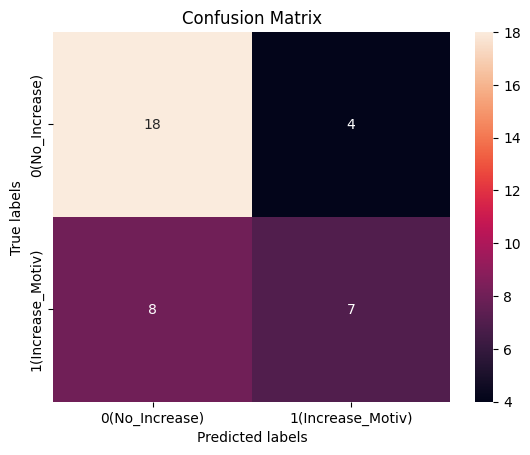

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])

## Random Forest

In [291]:
# James

rf_df = df.copy()

rf_df.dropna(subset=["Baseline_RRVscore"])

attr = rf_df.drop(columns = ['RRV_label'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
target = rf_df['RRV_label']  # target variable
attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size=0.3, random_state=6)


In [292]:
from C45 import C45Classifier
clf=C45Classifier()

clf.fit(attr_train, target_train)
target_pred = clf.predict(attr_test)

In [293]:
for column_name in rf_df.keys():
    rf_df[column_name] = pd.to_numeric(rf_df[column_name], errors='coerce')

print(rf_df.isnull().sum())

# Split the data into training and testing sets
attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size=0.3, random_state=6)

Assmnt                         0
Avg_Daily_Sed_Week_Min         0
Avg_Daily_Light_Week_Min       0
Avg_Daily_Mod_Week_Min         0
Avg_Daily_Vig_Week_Min         0
Avg_Daily_Very_Vig_Week_Min    0
RRV_label                      0
Baseline_RRVscore              0
dtype: int64


In [294]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,criterion='entropy', random_state=6)

model.fit(attr_train,target_train)
target_pred = model.predict(attr_test)

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(f"Accuracy= {accuracy_score(target_test,target_pred)}")

print(confusion_matrix(target_test,target_pred))
print(classification_report(target_test,target_pred))

feature_importance = model.feature_importances_

Accuracy= 0.7297297297297297
[[19  7]
 [ 3  8]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        26
           1       0.53      0.73      0.62        11

    accuracy                           0.73        37
   macro avg       0.70      0.73      0.70        37
weighted avg       0.77      0.73      0.74        37



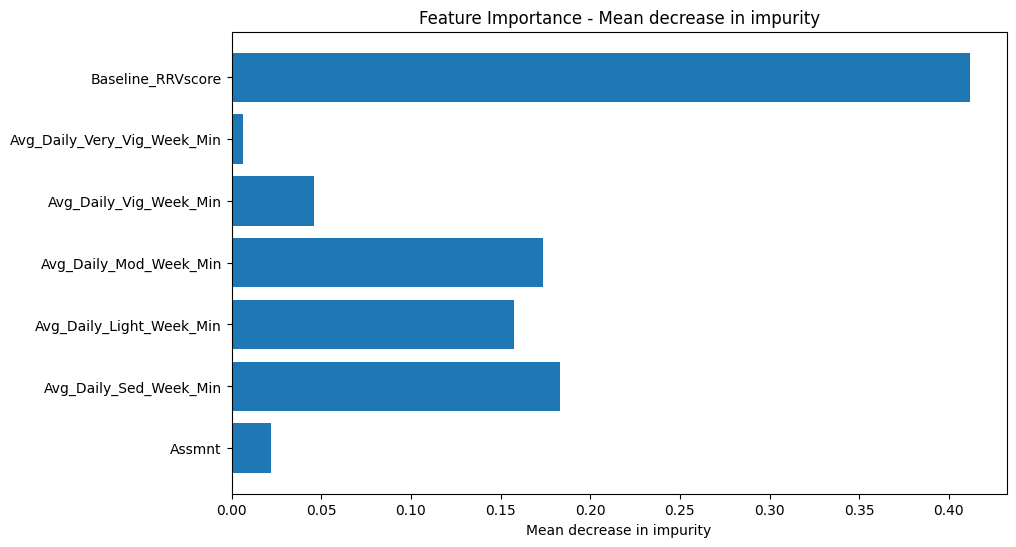

In [295]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance, align='center')
plt.yticks(range(len(feature_importance)), attr.columns)
plt.xlabel('Mean decrease in impurity')
plt.title('Feature Importance - Mean decrease in impurity')
plt.show()

0.7297297297297297
Assmnt  reduction in accuracy 0.0
Avg_Daily_Sed_Week_Min  reduction in accuracy 0.027027027027026973
Avg_Daily_Light_Week_Min  reduction in accuracy -0.027027027027027084
Avg_Daily_Mod_Week_Min  reduction in accuracy -0.027027027027027084
Avg_Daily_Vig_Week_Min  reduction in accuracy -0.027027027027027084
Avg_Daily_Very_Vig_Week_Min  reduction in accuracy 0.0
Baseline_RRVscore  reduction in accuracy 0.10810810810810811


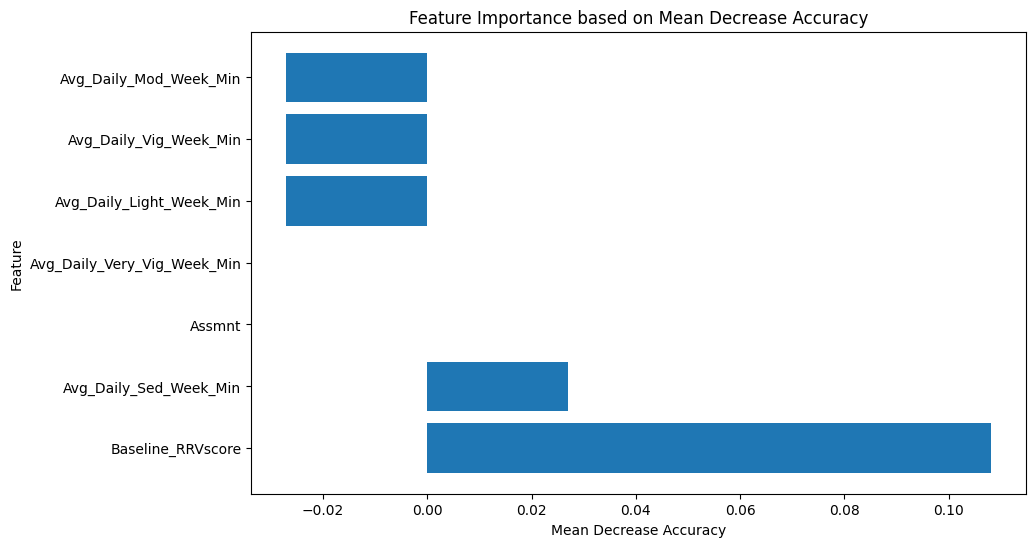

                       Feature  Importance
6            Baseline_RRVscore    0.108108
1       Avg_Daily_Sed_Week_Min    0.027027
0                       Assmnt    0.000000
5  Avg_Daily_Very_Vig_Week_Min    0.000000
2     Avg_Daily_Light_Week_Min   -0.027027
4       Avg_Daily_Vig_Week_Min   -0.027027
3       Avg_Daily_Mod_Week_Min   -0.027027


In [296]:
initial_accuracy = accuracy_score(target_test,target_pred)
print(initial_accuracy)

feature_importances = []

# Calculate Mean Decrease Accuracy for each feature

for i in range(attr_test.shape[1]):
    attr_test_permuted = attr_test.copy()
    np.random.shuffle(attr_test_permuted.iloc[:, i].values)
    permuted_accuracy = accuracy_score(target_test, model.predict(attr_test_permuted))
    feature_importances.append(initial_accuracy - permuted_accuracy)
    print( attr_test_permuted.columns[i],f" reduction in accuracy {initial_accuracy - permuted_accuracy}")

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': attr.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Mean Decrease Accuracy')
plt.ylabel('Feature')
plt.title('Feature Importance based on Mean Decrease Accuracy')
plt.show()

print(feature_importance_df)

In [297]:
single_tree = model.estimators_[1]
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(50,30), dpi=250)
plot_tree(single_tree,fontsize=20,filled=True,feature_names=attr.columns)

[Text(0.7619047619047619, 0.9444444444444444, 'Avg_Daily_Sed_Week_Min <= 1235.5\nentropy = 0.996\nsamples = 54\nvalue = [45, 39]'),
 Text(0.7142857142857143, 0.8333333333333334, 'Avg_Daily_Very_Vig_Week_Min <= 1.0\nentropy = 1.0\nsamples = 48\nvalue = [38.0, 39.0]'),
 Text(0.7380952380952381, 0.8888888888888888, 'True  '),
 Text(0.6666666666666666, 0.7222222222222222, 'Avg_Daily_Sed_Week_Min <= 1100.0\nentropy = 0.991\nsamples = 45\nvalue = [31, 39]'),
 Text(0.47619047619047616, 0.6111111111111112, 'Avg_Daily_Mod_Week_Min <= 19.5\nentropy = 0.996\nsamples = 38\nvalue = [30, 26]'),
 Text(0.2857142857142857, 0.5, 'Avg_Daily_Light_Week_Min <= 234.5\nentropy = 0.677\nsamples = 18\nvalue = [23, 5]'),
 Text(0.23809523809523808, 0.3888888888888889, 'Avg_Daily_Sed_Week_Min <= 694.0\nentropy = 0.874\nsamples = 10\nvalue = [12, 5]'),
 Text(0.14285714285714285, 0.2777777777777778, 'Avg_Daily_Sed_Week_Min <= 515.0\nentropy = 0.619\nsamples = 7\nvalue = [11, 2]'),
 Text(0.09523809523809523, 0.16666

## Artificial Neural Network (Nicolas)

In [298]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

In [300]:
# Split target variable and attributes
attr = df.drop(columns=['id', 'diagnosis'])
target = df['diagnosis']

KeyError: "['id', 'diagnosis'] not found in axis"

## Hierarchical Clustering

## K-Means Clustering

## Support Vector Machine

## MiniSOM